In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
 
np.random.seed(42)
print('Ready.')


Ready.


In [6]:
df = pd.read_csv("omantel_subscribers.csv")

print(df.shape)
df.head()

(2500, 8)


,msisdn,tenure_months,data_usage_gb,monthly_spend_omr,intl_minutes,roaming_days,voice_minutes,true_persona
0,96890000000,9.1,55.1,11.5,0.0,1.9,514.7,Heavy-Data Youth
1,96890000001,14.9,58.9,12.9,11.2,1.0,445.8,Heavy-Data Youth
2,96890000002,17.5,64.7,14.2,0.4,0.3,0.0,Heavy-Data Youth
3,96890000003,15.8,3.8,29.5,136.1,13.0,303.6,Frequent Roamer
4,96890000004,70.2,28.1,42.2,54.8,2.6,515.5,Business Postpaid


In [11]:
FEATURES = [
    "tenure_months",
    "data_usage_gb",
    "monthly_spend_omr",
    "intl_minutes",
    "roaming_days",
    "voice_minutes"
]

df[FEATURES].describe().round(1)

,tenure_months,data_usage_gb,monthly_spend_omr,intl_minutes,roaming_days,voice_minutes
count,2500.0,2500.0,2500.0,2500.0,2500.0,2500.0
mean,26.1,23.3,21.0,52.8,3.1,473.0
std,17.4,24.8,15.4,68.5,4.9,317.9
min,1.0,0.1,2.0,0.0,0.0,0.0
25%,13.5,2.6,7.1,3.0,0.1,225.6
50%,20.9,15.3,17.6,8.1,0.7,459.6
75%,35.6,32.8,31.4,99.6,2.9,682.4
max,84.0,103.7,71.2,307.9,21.9,1555.2


In [12]:
km_raw = KMeans(n_clusters=4, random_state=42, n_init=10)

df["segment_raw"] = km_raw.fit_predict(df[FEATURES])

df.groupby("segment_raw")[FEATURES].mean().round(1)

,tenure_months,data_usage_gb,monthly_spend_omr,intl_minutes,roaming_days,voice_minutes
segment_raw,,,,,,
0,26.3,23.4,21.6,52.8,3.0,85.2
1,25.8,22.8,20.1,49.7,3.0,669.7
2,25.9,23.4,20.8,52.9,3.1,391.4
3,27.0,24.1,22.4,58.9,3.2,1018.6


In [13]:
df[FEATURES].std().round(1)

tenure_months         17.4
data_usage_gb         24.8
monthly_spend_omr     15.4
intl_minutes          68.5
roaming_days           4.9
voice_minutes        317.9
dtype: float64

In [14]:
scaler = StandardScaler()

X = scaler.fit_transform(df[FEATURES])

km = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df["segment"] = km.fit_predict(X)

print(df["segment"].value_counts().sort_index())

segment
0    509
1    610
2    892
3    489
Name: count, dtype: int64


In [15]:
df.groupby("segment")[FEATURES].mean().round(1)

,tenure_months,data_usage_gb,monthly_spend_omr,intl_minutes,roaming_days,voice_minutes
segment,,,,,,
0,53.6,21.7,44.7,88.6,2.1,477.2
1,17.5,62.5,17.0,6.3,0.7,473.1
2,14.1,2.6,6.2,3.4,0.3,467.5
3,30.2,13.9,28.4,163.4,12.2,478.6


In [16]:
names = {
    0: "Loyal High-Value",
    1: "Heavy-Data Youth",
    2: "Low-Use Prepaid",
    3: "Frequent Roamer"
}

df["segment_name"] = df["segment"].map(names)

df.groupby("segment_name")[FEATURES].mean().round(1)

,tenure_months,data_usage_gb,monthly_spend_omr,intl_minutes,roaming_days,voice_minutes
segment_name,,,,,,
Frequent Roamer,30.2,13.9,28.4,163.4,12.2,478.6
Heavy-Data Youth,17.5,62.5,17.0,6.3,0.7,473.1
Low-Use Prepaid,14.1,2.6,6.2,3.4,0.3,467.5
Loyal High-Value,53.6,21.7,44.7,88.6,2.1,477.2


In [17]:
comparison = df[
    [
        "msisdn",
        "true_persona",
        "segment_name"
    ] + FEATURES
]

comparison.to_csv(
    "omantel_segmentation_results.csv",
    index=False
)

print("Report generated successfully.")
print("Saved:", comparison.shape)

comparison.head()

Report generated successfully.
Saved: (2500, 9)


,msisdn,true_persona,segment_name,tenure_months,data_usage_gb,monthly_spend_omr,intl_minutes,roaming_days,voice_minutes
0,96890000000,Heavy-Data Youth,Heavy-Data Youth,9.1,55.1,11.5,0.0,1.9,514.7
1,96890000001,Heavy-Data Youth,Heavy-Data Youth,14.9,58.9,12.9,11.2,1.0,445.8
2,96890000002,Heavy-Data Youth,Heavy-Data Youth,17.5,64.7,14.2,0.4,0.3,0.0
3,96890000003,Frequent Roamer,Frequent Roamer,15.8,3.8,29.5,136.1,13.0,303.6
4,96890000004,Business Postpaid,Loyal High-Value,70.2,28.1,42.2,54.8,2.6,515.5


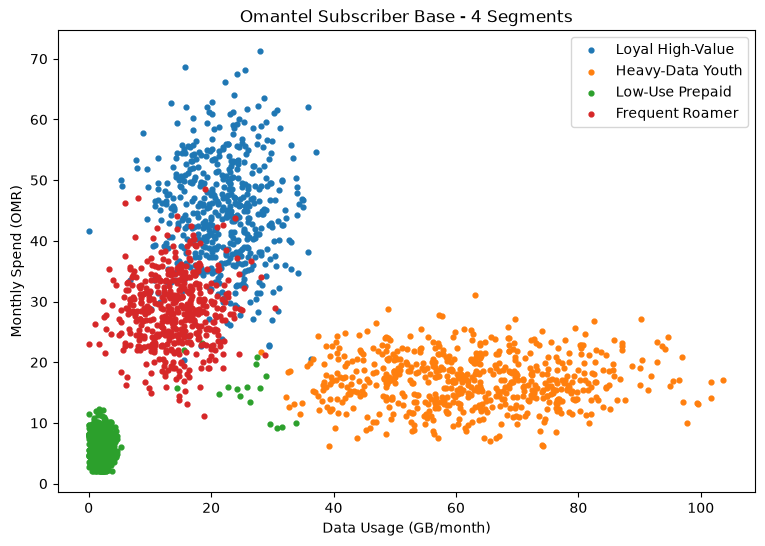

In [19]:
plt.figure(figsize=(9,6))

for s in sorted(df["segment"].unique()):
    d = df[df["segment"] == s]

    plt.scatter(
        d["data_usage_gb"],
        d["monthly_spend_omr"],
        s=12,
        label=names[s]
    )

plt.xlabel("Data Usage (GB/month)")
plt.ylabel("Monthly Spend (OMR)")
plt.title("Omantel Subscriber Base - 4 Segments")
plt.legend()

plt.show()

In [20]:
pd.crosstab(
    df["segment_name"],
    df["true_persona"]
)

true_persona,Business Postpaid,Frequent Roamer,Heavy-Data Youth,Low-Use Prepaid
segment_name,,,,
Frequent Roamer,0,489,0,0
Heavy-Data Youth,0,0,610,0
Low-Use Prepaid,0,2,15,875
Loyal High-Value,500,9,0,0
